In [28]:
import json
import os
import sys

import ee
import folium
import geemap.foliumap as geemap
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import rioxarray
import shapely.ops
import xarray as xr
from geotessera import GeoTessera, dequantize_embedding
import numpy as np
from pathlib import Path
from pyproj import Transformer
from rasterio.features import rasterize
from rasterio.transform import Affine, from_bounds
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, RobustScaler

In [23]:
ee.Authenticate()
ee.Initialize(project="vital-wavelet-217112")

gt = GeoTessera()

RASTERS_PATH = "./dataset/rasters"
os.makedirs(RASTERS_PATH, exist_ok=True)

In [88]:
tile = gpd.read_file("./dataset/tile_C51L41_WGS84.gpkg")
if tile.crs != "EPSG:4326":
    tile = tile.to_crs(epsg=4326)
tile_id_ = tile.iloc[0]["id"]
min_lon, min_lat, max_lon, max_lat = tile.total_bounds
center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]
bbox = list([ float(b) for b in tile.total_bounds ])
min_lon, min_lat, max_lon, max_lat = bbox
print(tile.crs)
print(bbox)
print(center)
print(tile_id_)

EPSG:4326
[-61.25000000000001, -8.25, -61.0, -7.999999999999998]
[np.float64(-8.125), np.float64(-61.125)]
C51L41


In [26]:
year = 2024
label = "class"
label_column = "CLASS"

samples = gpd.read_file("./dataset/Deter20_24_C51L41.gpkg")
samples = samples[samples["DATE"].dt.year == year]
# samples = samples[samples[label_column] == label]
if samples.crs != "EPSG:4326":
    samples = samples.to_crs(epsg=4326)
samples = samples.drop(columns=["DATE"])
samples.head()

,id,i,CLASS,PATH_ROW,SENSOR,SATELLITE,YEAR,area_rel,AREA_FDAS,geometry
79,C51L41,4.0,CICATRIZ_DE_QUEIMADA,038016,WFI,AMAZONIA-1,2024.0,99.022909,1.572381e+04,"MULTIPOLYGON (((-61.18527 -8.17377, -61.18588 ..."
80,C51L41,4.0,CS_GEOMETRICO,174111,AWFI,CBERS-4,2024.0,99.022909,1.280296e+06,"MULTIPOLYGON (((-61.14624 -8.09999, -61.15007 ..."
81,C51L41,4.0,CICATRIZ_DE_QUEIMADA,038016,WFI,AMAZONIA-1,2024.0,99.022909,2.650055e+05,"MULTIPOLYGON (((-61.18551 -8.17037, -61.18583 ..."
82,C51L41,4.0,CICATRIZ_DE_QUEIMADA,038016,WFI,AMAZONIA-1,2024.0,99.022909,1.338933e+06,"MULTIPOLYGON (((-61.17153 -8.17087, -61.17157 ..."
83,C51L41,4.0,CICATRIZ_DE_QUEIMADA,038016,WFI,AMAZONIA-1,2024.0,99.022909,2.375898e+04,"MULTIPOLYGON (((-61.17901 -8.10486, -61.17901 ..."


In [27]:
year = 2024
label = "Deter_Deg_CsG"
label_column = "class_multisource"

samples = gpd.read_file("./dataset/Aut_C51L41_preclass.gpkg")
samples = samples[samples["date_multisource"].dt.year == year]
samples = samples[samples[label_column] == label]
if samples.crs != "EPSG:4326":
    samples = samples.to_crs(epsg=4326)
samples['id'] = samples['idx']
samples = samples.drop(columns=["idx", "date", "date_multisource"])
samples.head()

,doy_2020,class_multisource,geometry,id
73,7,Deter_Deg_CsG,"POLYGON ((-61.1488 -8.0953, -61.1489 -8.0953, ...",74
6720,212,Deter_Deg_CsG,"POLYGON ((-61.1597 -8.108, -61.1596 -8.108, -6...",6721
7628,217,Deter_Deg_CsG,"POLYGON ((-61.1595 -8.108, -61.1595 -8.1081, -...",7629
7629,217,Deter_Deg_CsG,"POLYGON ((-61.1597 -8.1078, -61.1597 -8.1081, ...",7630
10816,227,Deter_Deg_CsG,"POLYGON ((-61.1596 -8.1079, -61.1596 -8.108, -...",10817


In [ ]:
tiles_to_fetch = gt.fetch_mosaic_for_region(bbox = bbox, year = year, target_crs = tile.crs)
tiles_to_fetch

In [ ]:
import numpy as np
import xarray as xr
import rioxarray
from rioxarray.merge import merge_arrays
from sklearn.decomposition import PCA
import rasterio
import rasterio.transform
from rasterio.transform import from_bounds

def dequantize(quantized, scales):
    if scales.ndim == 2 and quantized.ndim == 3:
        scales = scales[:, :, np.newaxis]
    return quantized.astype(np.float32) * scales

# 1. Busca todos os blocos dentro do bbox global (9 blocos 0.1°)
tiles_to_fetch = gt.registry.load_blocks_for_region(bounds=bbox, year=year)
tiles = gt.fetch_embeddings(tiles_to_fetch)

tile_arrays = []

for tile_year, tile_lon, tile_lat, _, crs, transform in tiles:
    tile_id = f"grid_{tile_lon:.2f}_{tile_lat:.2f}"
    base_path = f"./global_0.1_degree_representation/{tile_year}/{tile_id}/{tile_id}"
    
    # Carrega os arquivos brutos de cada célula
    quantized = np.load(f"{base_path}.npy")
    scales = np.load(f"{base_path}_scales.npy")
    
    # Desquantiza (H, W, 128)
    emb = dequantize(quantized, scales)
    h, w, d = emb.shape
    
    # Coordenadas reais dos centros dos pixels via matriz afim oficial
    cols = np.arange(w)
    rows = np.arange(h)
    
    xs, _ = rasterio.transform.xy(transform, np.zeros_like(cols), cols, offset='center')
    _, ys = rasterio.transform.xy(transform, rows, np.zeros_like(rows), offset='center')
    
    # Cria o DataArray (128, H, W)
    da_tile = xr.DataArray(
        np.transpose(emb, (2, 0, 1)),
        dims=["band", "y", "x"],
        coords={"band": np.arange(d), "y": np.array(ys), "x": np.array(xs)}
    )
    
    # Define o CRS e a transformação afim no rioxarray
    tile_crs = crs if crs is not None else "EPSG:4326"
    da_tile.rio.write_crs(tile_crs, inplace=True)
    da_tile.rio.write_transform(transform, inplace=True)
    da_tile.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
    
    tile_arrays.append(da_tile)
    print(tile_lon, tile_lat)

# 2. Mescla os blocos em um único raster contínuo
if len(tile_arrays) > 1:
    da_mosaic = merge_arrays(tile_arrays)
else:
    da_mosaic = tile_arrays[0]

print(f"Shape do Mosaico Completo: {da_mosaic.shape}")

# 3. PCA no mosaico completo
n_bands, n_y, n_x = da_mosaic.shape
flat_data = da_mosaic.values.transpose(1, 2, 0).reshape(-1, n_bands)

valid_mask = ~np.isnan(flat_data).any(axis=1)
pca = PCA(n_components=3)
transformed = pca.fit_transform(flat_data[valid_mask])

# 4. Normalização Robusta [0, 1] (percentis 2% e 98%)
p2, p98 = np.percentile(transformed, (2, 98), axis=0)
diff = np.where((p98 - p2) == 0, 1.0, (p98 - p2))
transformed_scaled = np.clip((transformed - p2) / diff, 0.0, 1.0)

pca_result = np.full((n_y * n_x, 3), np.nan, dtype=np.float32)
pca_result[valid_mask] = transformed_scaled
pca_rgb_raster = pca_result.reshape(n_y, n_x, 3).transpose(2, 0, 1)

# 5. Salva o mosaico RGB final
minx, miny, maxx, maxy = da_mosaic.rio.bounds()
transform_final = from_bounds(minx, miny, maxx, maxy, n_x, n_y)

wgs84_wkt = (
    'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],'
    'PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],'
    'AUTHORITY["EPSG","4326"]]'
)

tif_pca_path = f"./tessera_mosaic_{year}_pcargb.tif"

with rasterio.open(
    tif_pca_path,
    "w",
    driver="GTiff",
    height=n_y,
    width=n_x,
    count=3,
    dtype="float32",
    crs=wgs84_wkt,
    transform=transform_final,
    nodata=np.nan
) as dst:
    dst.write(pca_rgb_raster)

print(f"Mosaico completo salvo com sucesso em: {tif_pca_path}")

-61.25 -8.25
-61.15 -8.25
-61.05 -8.25


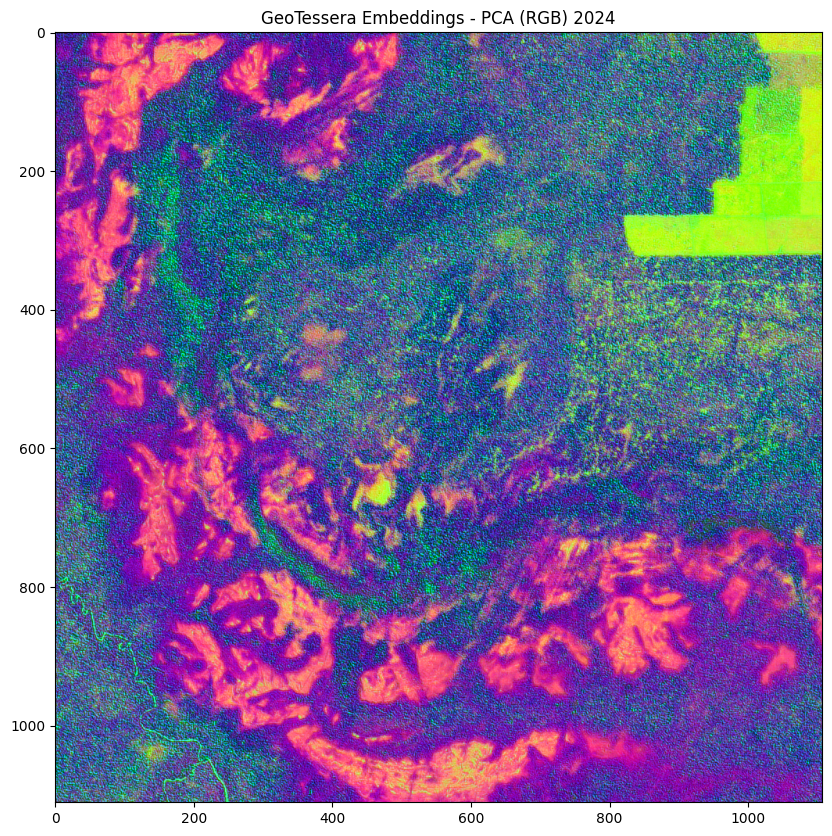

In [102]:
da_rgb = rioxarray.open_rasterio(tif_pca_path, chunks="auto")

plt.figure(figsize=(10, 10))
plt.imshow(da_rgb.values.transpose(1, 2, 0))
plt.title(f"GeoTessera Embeddings - PCA (RGB) {year}")
plt.show()


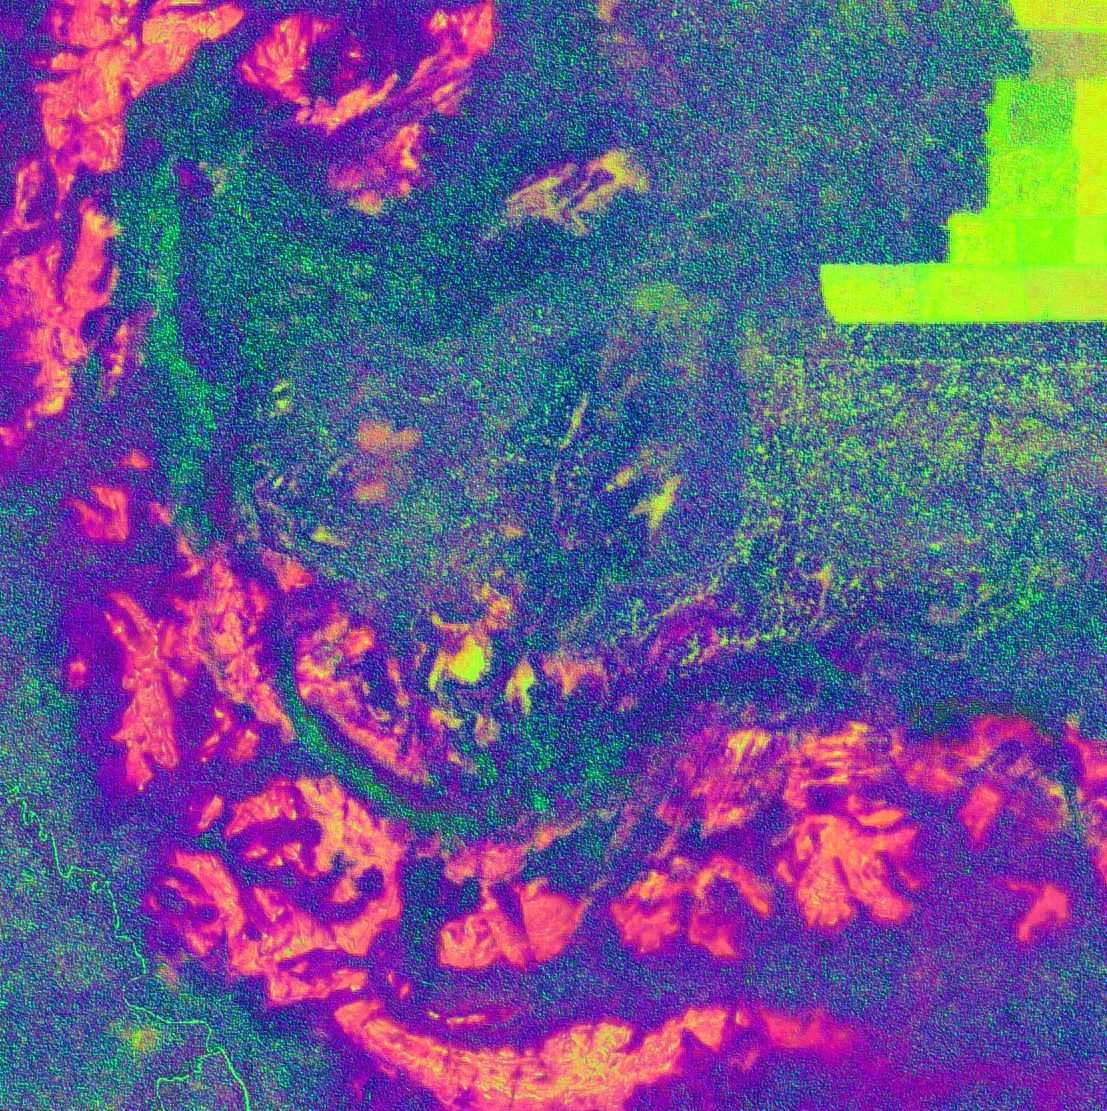

In [108]:
# 3. Cria o mapa interativo
Map = folium.Map(location=center, zoom_start=12, tiles="OpenStreetMap")

# 4. Adiciona a camada de satélite como base opcional
folium.TileLayer(
    tiles="https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
    attr="Google Satellite",
    name="Google Satellite"
).add_to(Map)

# 1. Defina a caixa exata da célula inferior esquerda
# Se o centro for -61.25 -8.25 (com tamanho de 0.1 x 0.1):
cell_min_lon = -61.25 - 0.05  # -61.00
cell_max_lon = -61.25 + 0.05  # -60.90
cell_min_lat = -8.25 - 0.05   # -8.00
cell_max_lat = -8.25 + 0.05   # -7.90

# (Ou use os bounds exatos do geojson se tiver o polígono daquela célula específica)

# 2. Renderiza no Folium com o bounding box ajustado para esta célula:
folium.raster_layers.ImageOverlay(
    image=np.clip(da_rgb.values.transpose(1, 2, 0), 0.0, 1.0),
    bounds=[[cell_min_lat, cell_min_lon], [cell_max_lat, cell_max_lon]],
    opacity=0.7,  # Opacidade intermediária para validar a sobreposição visual
    name="Tessera PCA RGB (Célula Inferior Esquerda)"
).add_to(Map)

folium.GeoJson(
    tile,
    name="Tile C51L41",
    style_function=lambda feature: {
        "fillColor": "#ff7800",
        "color": "#000000",       # Cor da borda
        "weight": 2,              # Espessura da borda
        "fillOpacity": 0.2,       # Transparência do preenchimento
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[col for col in tile.columns if col != "geometry"][:3],  # Mostra até 3 colunas de atributos
        localize=True
    )
).add_to(Map)

folium.GeoJson(
    samples,
    name=f"DETER Samples Distúrbios {label}",
    style_function=lambda feature: {
        "fillColor": "#ff7800",
        "color": "#000000",       # Cor da borda
        "weight": 2,              # Espessura da borda
        "fillOpacity": 0.2,       # Transparência do preenchimento
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[col for col in samples.columns if col != "geometry"][:3],  # Mostra até 3 colunas de atributos
        localize=True
    )
).add_to(Map)

folium.LayerControl().add_to(Map)

Map

In [50]:
# 1. Transformadores PROJ
proj4_utm20s = "+proj=utm +zone=20 +south +datum=WGS84 +units=m +no_defs"
transformer_to_utm = Transformer.from_crs(
    "EPSG:4326", proj4_utm20s, always_xy=True
)
transformer_to_wgs84 = Transformer.from_crs(
    proj4_utm20s, "EPSG:4326", always_xy=True
)

# 2. Projetar geometrias e criar GeoDataFrame com CRS UTM explícito
samples_utm_geoms = [
    shapely.ops.transform(transformer_to_utm.transform, geom)
    for geom in samples.geometry
]

# Cria o GeoDataFrame já com o CRS métrico definido (remove o UserWarning)
samples_utm = gpd.GeoDataFrame(
    samples.drop(columns="geometry"),
    geometry=samples_utm_geoms,
    crs="EPSG:32720",
)

# 3. Calcular deslocamento exato e alinhar o grid do xarray
sample_utm_x = float(samples_utm.geometry.centroid.x.mean())
sample_utm_y = float(samples_utm.geometry.centroid.y.mean())
raster_utm_x = float(da_tessera.x.mean())
raster_utm_y = float(da_tessera.y.mean())

delta_x = sample_utm_x - raster_utm_x
delta_y = sample_utm_y - raster_utm_y

# Aplica a translação nas coordenadas x, y
da_aligned = da_tessera.assign_coords(
    x=da_tessera.x + delta_x, y=da_tessera.y + delta_y
)

# 4. Construir o Grid e o Affine Transform
x_coords = da_aligned.x.values
y_coords = da_aligned.y.values

minx, maxx = float(x_coords.min()), float(x_coords.max())
miny, maxy = float(y_coords.min()), float(y_coords.max())
width, height = len(x_coords), len(y_coords)

transform = from_bounds(minx, miny, maxx, maxy, width, height)
shape = (height, width)

# 5. Rasterização dos polígonos
geom_pairs = [
    (geom, idx)
    for idx, geom in enumerate(samples_utm.geometry)
    if geom.is_valid and not geom.is_empty
]

mask_poly = rasterize(
    shapes=geom_pairs,
    out_shape=shape,
    transform=transform,
    fill=-1,
    all_touched=True,
    dtype=np.int32,
)

y_indices, x_indices = np.where(mask_poly != -1)
poly_indices = mask_poly[y_indices, x_indices]

print(f"Total de pixels interceptados: {len(x_indices)}")

# 6. Extração dos Embeddings
if len(x_indices) > 0:
    x_vals = x_coords[x_indices]
    y_vals = y_coords[y_indices]

    pixel_lons, pixel_lats = transformer_to_wgs84.transform(x_vals, y_vals)

    x_da = xr.DataArray(x_vals, dims="pixel")
    y_da = xr.DataArray(y_vals, dims="pixel")

    sampled_embeddings = (
        da_aligned["band_data"]
        .sel(x=x_da, y=y_da, method="nearest")
        .transpose("pixel", "band")
        .values
    )

    records = []
    for pix_i in range(len(x_indices)):
        p_idx = poly_indices[pix_i]
        row = samples.iloc[p_idx]

        emb_vector = sampled_embeddings[pix_i].tolist()
        emb_json = json.dumps({"embeddings": emb_vector})

        records.append({
            "longitude": pixel_lons[pix_i],
            "latitude": pixel_lats[pix_i],
            "label": row[label_column],
            "cube": "da_tessera",
            "embeddings": emb_json,
        })

    df_tessera_embeddings = pd.DataFrame(records)
    print(df_tessera_embeddings.head())

Total de pixels interceptados: 5721
   longitude  latitude          label        cube  \
0 -61.153808 -8.090320  Deter_Deg_CsG  da_tessera   
1 -61.153717 -8.090320  Deter_Deg_CsG  da_tessera   
2 -61.153626 -8.090319  Deter_Deg_CsG  da_tessera   
3 -61.153807 -8.090411  Deter_Deg_CsG  da_tessera   
4 -61.153717 -8.090410  Deter_Deg_CsG  da_tessera   

                                          embeddings  
0  {"embeddings": [3.47117018699646, -3.092497110...  
1  {"embeddings": [2.0581207275390625, -2.7080535...  
2  {"embeddings": [3.735261917114258, -2.38190627...  
3  {"embeddings": [4.6073222160339355, -4.1829638...  
4  {"embeddings": [3.564690589904785, -2.96050596...  


In [61]:
# # Extrai a lista de embeddings de cada linha do DataFrame existente
# emb_matrix = np.array(
#     [json.loads(row)["embeddings"] for row in df_tessera_embeddings["embeddings"]]
# )

# # Cria as colunas T0, T1, T2...
# col_names = [f"T{i}" for i in range(emb_matrix.shape[1])]
# df_features = pd.DataFrame(emb_matrix, columns=col_names)

# # Substitui a coluna JSON pelas novas colunas
# df_tessera_embeddings = pd.concat(
#     [df_tessera_embeddings.drop(columns=["embeddings"]), df_features], axis=1
# )

# "samples_Deter_Deg_CsG_2024_embeddings_pixel"

df_tessera_embeddings.to_csv(f"./dataset/samples/samples_{label}_{year}_embeddings_tessera_pixel.csv", index=False)
df_tessera_embeddings.head()

,longitude,latitude,label,cube,T0,T1,T2,T3,T4,T5,...,T118,T119,T120,T121,T122,T123,T124,T125,T126,T127
0,-61.153808,-8.090320,Deter_Deg_CsG,da_tessera,3.471170,-3.092497,2.524487,2.650712,1.830253,1.956478,...,-3.786731,-3.660507,-1.704029,-4.165404,-8.015247,4.039180,-5.112087,0.126224,1.388468,-0.126224
1,-61.153717,-8.090320,Deter_Deg_CsG,da_tessera,2.058121,-2.708054,1.678993,1.570671,1.299866,1.462349,...,-4.224564,-3.737114,-2.058121,-3.845436,-6.878456,4.549530,-3.791275,0.595772,1.570671,-0.758255
2,-61.153626,-8.090319,Deter_Deg_CsG,da_tessera,3.735262,-2.381906,1.894698,1.678161,1.515759,1.082685,...,-4.709678,-4.114202,-1.299222,-3.735262,-6.171302,3.951799,-2.814980,0.433074,2.814980,-0.757879
3,-61.153807,-8.090411,Deter_Deg_CsG,da_tessera,4.607322,-4.182964,1.091208,1.939925,0.727472,1.697435,...,-4.425454,-3.213001,-1.758057,-4.122341,-7.699078,3.697982,-4.122341,0.000000,2.788642,-1.273076
4,-61.153717,-8.090410,Deter_Deg_CsG,da_tessera,3.564691,-2.960506,0.845859,3.564691,2.416739,1.450044,...,-3.564691,-4.410550,-0.785440,-3.625109,-6.948126,2.960506,-4.470968,-0.483348,2.477158,0.060418


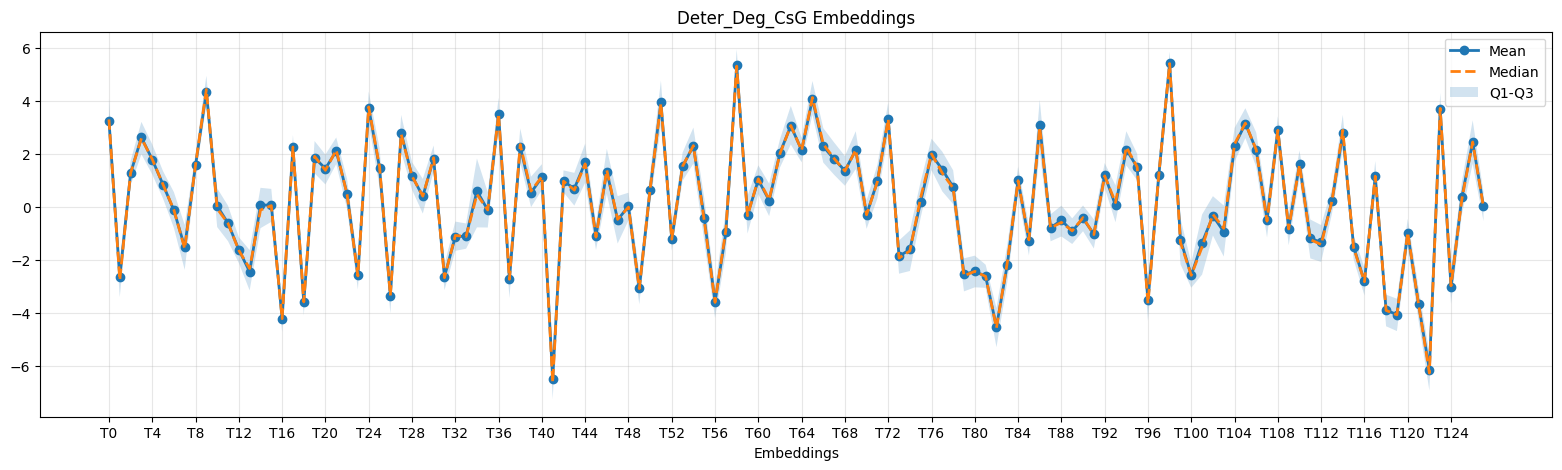

In [60]:
def generatePlotFigPatterns(data, label, smoothing = False, window_length = 7, polyorder = 2):
    only_values = data
    # Statistics
    mean_values = only_values.mean(axis=0)
    median_values = only_values.median(axis=0)
    q1 = only_values.quantile(0.25, axis=0)
    q3 = only_values.quantile(0.75, axis=0)

    if smoothing:
        mean_values = savgol_filter(mean_values, window_length=window_length, polyorder=polyorder)
        median_values = savgol_filter(median_values, window_length=window_length, polyorder=polyorder)
        q1 = savgol_filter(q1, window_length=window_length, polyorder=polyorder)
        q3 = savgol_filter(q3, window_length=window_length, polyorder=polyorder)
        
    # Dates
    indexes = data.columns
    # Plot
    fig, ax = plt.subplots(figsize=(18, 5))
    # Mean curve
    ax.plot(
        indexes,
        mean_values,
        marker="o",
        linewidth=2,
        label="Mean"
    )
    # Median curve
    ax.plot(
        indexes,
        median_values,
        linestyle="--",
        linewidth=2,
        label="Median"
    )
    # Quartile interval
    ax.fill_between(
        indexes,
        q1,
        q3,
        alpha=0.2,
        label="Q1-Q3"
    )
    fig.subplots_adjust(left = 0.06)
    ax.set_title(f"{label} Embeddings")
    ax.set_xlabel("Embeddings")
    ax.legend()
    plt.xticks(range(0, 128, 4))
    # plt.ylim(-0.4, 0.4)
    plt.grid(True, alpha=0.3)
    plt.show()

labels = set(df_tessera_embeddings["label"])
for label in labels:
    data_ = df_tessera_embeddings[df_tessera_embeddings["label"] == label]
    generatePlotFigPatterns(data_[col_names], label)